In [95]:
import pandas as pd
import numpy as np 

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


In [96]:
train_dataset = pd.read_csv("../../classiicacao/train2.csv")
test_dataset = pd.read_csv("../../classiicacao/test2.csv")

# EDA

In [97]:
print(train_dataset.head(), test_dataset.head())

  diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0         M        17.99         10.38          122.80     1001.0   
1         M        20.57         17.77          132.90     1326.0   
2         M        19.69         21.25          130.00     1203.0   
3         M        11.42         20.38           77.58      386.1   
4         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   symmetry_mean  ...  radius_worst  texture_worst  perimeter_worst  \
0         0.2419  ...         25.38          17.33 

# Limpeza

Vendo a tabela, é claro que a predição se baseia em 3 fatores conjuntos, a média deslocada do natural, valores "worst" minimamente significativos e desvios padrões consideráveis. Somente a média deslocada pode indicar uma alteração genética da pessoa, e apenas worst podem ser um outlier sem volume o suficiente para dar o diagnóstico. Desvio padrão alto é algo mais consistente, mas ainda assim, podemos chegar na conclusão que não podemos descartar variáveis, todas tem funções e não são necessariamente correlatas. 

Além disso, por se tratarem apenas de dados numéricos, não há uma grande limpeza a ser feita, apenas trocar os dados de diagnoses M por 1 e B por 0 (tornar numérico, para ficar mais claro, mas não faz diferença, exatamente)

Nesse trabalho, se pede acurácia e um plot da matriz de confusão, então vou ter que separar entre train e val.

In [98]:
df_train, df_val = train_test_split(
    train_dataset, 
    test_size=0.3, 
    stratify=train_dataset['diagnosis']
)
X_train = df_train.drop(columns='diagnosis')
y_train = df_train['diagnosis']
X_val = df_val.drop(columns='diagnosis')
y_val = df_val['diagnosis']

In [99]:
binary_mappings = {
    'diagnosis': {'B': 0, 'M':1}
}
X_train = X_train.replace(binary_mappings)
X_val = X_val.replace(binary_mappings)
test_dataset = test_dataset.replace(binary_mappings)


In [100]:
modelos = {
    "Regressão Logística": LogisticRegression(max_iter=1400),
    "Árvore de Decisão": DecisionTreeClassifier(max_depth=7),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=6)
}

for nome, modelo in modelos.items():
    modelo.fit(X_train, y_train)


c:\Users\nb1_l\anaconda3\envs\analytica\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1400 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1400).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Agora, fazendo as previsões no próprio train data pra ver overfitting

In [101]:

for nome, modelo in modelos.items():
    predicoes = modelo.predict(X_train)
    acuracia = accuracy_score(y_train, predicoes)
    print(f"Modelo Estimador: {nome}")
    print(f"Acurácia Global: {acuracia:.4f}")

Modelo Estimador: Regressão Logística
Acurácia Global: 0.9623
Modelo Estimador: Árvore de Decisão
Acurácia Global: 1.0000
Modelo Estimador: Random Forest
Acurácia Global: 0.9975


Com esses dados de acurácia (o primeiro foi 0.95 RL, 1.0 DT, 0.99 RF), consegui ver possíveis underfittings do meus modelos (não foi o caso desde o começo)

c:\Users\nb1_l\anaconda3\envs\analytica\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1400 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1400).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


 O modelo Regressão Logística teve acurácia 0.9298245614035088
 O modelo Árvore de Decisão teve acurácia 0.9415204678362573
 O modelo Random Forest teve acurácia 0.9532163742690059


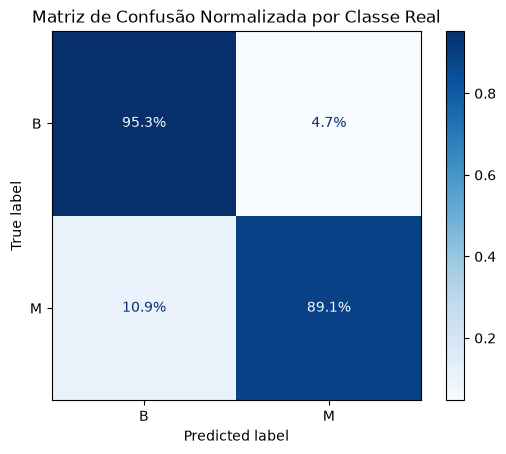

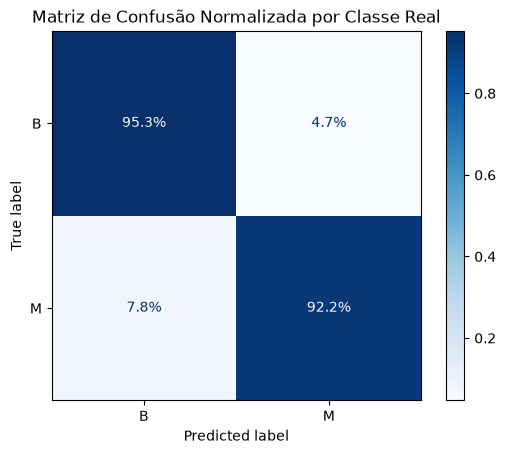

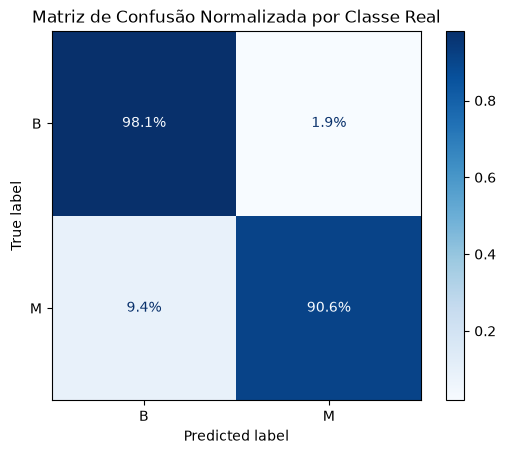

In [102]:
for nome, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    
    predicoes = modelo.predict(X_val)
    
    acuracia = accuracy_score(y_val, predicoes)
    
    cm_normalized = confusion_matrix(y_val, predicoes, labels=['B', 'M'], normalize='true')
    print(f" O modelo {nome} teve acurácia {acuracia}")
    # Renderize com a barra de cores de porcentagem (0 a 1)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=['B', 'M'])
    disp.plot(cmap='Blues', values_format='.1%') # Use format de porcentagem
    disp.ax_.set_title('Matriz de Confusão Normalizada por Classe Real')

Os valores de acurácia revelaram que o grau de overfitting não foi alto, e averiguando a matriz de confusão, percebi que todos os modelos tendem à prever mais B's do que M's, muito provavelmente devido à desproporção no dataset de treino. Mesmo assim, os valores não foram gritantes. Com mudanças, visando menor overfitting, cheguei num ponto onde o erro total aumentou, mas tinha menos bias de B/M. Por isso, fiz apenas um pequeno ajuste fino após isso, mas sem mudar muito.

Com isso, agora vamos rodar com o dataset de teste, e colocar no kaggle

In [103]:
for nome, modelo in modelos.items():
    resultado = modelo.predict(test_dataset)
    dataframe_resultado = pd.DataFrame({
    'id': range(len(resultado)),
    'diagnosis': resultado
    })
    dataframe_resultado.to_csv(f"submission{nome}.csv", index=False)
